In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/brain-tumour-mri-classification/data

Testing  Training


In [3]:
token_ = None
from google.colab import userdata
token_ = userdata.get('GITHUB_TOKEN')
!git clone -b feature/resnet50 https://{token_}@github.com/Dini-s/brain-tumour-mri-classification.git

import sys
sys.path.append('/content/brain-tumour-mri-classification')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from src.dataset import get_dataloaders
from src.utils import evaluate_model, plot_confusion_matrix, plot_learning_curves, print_metrics

!mkdir -p /content/data
!cp -r "/content/drive/MyDrive/brain-tumour-mri-classification/data/Training" /content/data/
!cp -r "/content/drive/MyDrive/brain-tumour-mri-classification/data/Testing" /content/data/

DATA_ROOT = '/content/data'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
train_loader, val_loader, test_loader = get_dataloaders(DATA_ROOT, batch_size=32)

Cloning into 'brain-tumour-mri-classification'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 23 (delta 2), reused 20 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 7.45 KiB | 3.72 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Using device: cuda
Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
print(resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
num_classes = 4
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)
print(resnet.fc)

Linear(in_features=2048, out_features=4, bias=True)


In [6]:
# Freeze every parameter first
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze layer4 (last residual stage) and the new classifier head
for param in resnet.layer4.parameters():
    param.requires_grad = True
for param in resnet.fc.parameters():
    param.requires_grad = True

# Sanity check: how much of the network is actually trainable?
total_params = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

Trainable params: 14,972,932 / 23,516,228 (63.7%)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4)

In [8]:
import time
import os

os.makedirs('/content/drive/MyDrive/brain-tumour-mri-classification/results/checkpoints', exist_ok=True)
CHECKPOINT_PATH = '/content/drive/MyDrive/brain-tumour-mri-classification/results/checkpoints/resnet50_best.pth'

num_epochs = 25
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    start = time.time()

    # ---- Training phase ----
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation phase ----
    resnet.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    # Save checkpoint if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet.state_dict(), CHECKPOINT_PATH)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"{elapsed:.1f}s")

Epoch 1/25 | train_loss=0.4987 train_acc=0.8342 | val_loss=0.2787 val_acc=0.9062 | 39.1s
Epoch 2/25 | train_loss=0.1949 train_acc=0.9270 | val_loss=0.1925 val_acc=0.9393 | 37.7s
Epoch 3/25 | train_loss=0.1233 train_acc=0.9587 | val_loss=0.1720 val_acc=0.9384 | 37.7s
Epoch 4/25 | train_loss=0.0850 train_acc=0.9712 | val_loss=0.1455 val_acc=0.9580 | 39.2s
Epoch 5/25 | train_loss=0.0769 train_acc=0.9737 | val_loss=0.2117 val_acc=0.9571 | 37.6s
Epoch 6/25 | train_loss=0.0599 train_acc=0.9812 | val_loss=0.5072 val_acc=0.9607 | 37.7s
Epoch 7/25 | train_loss=0.0495 train_acc=0.9828 | val_loss=0.1634 val_acc=0.9652 | 35.8s
Epoch 8/25 | train_loss=0.0544 train_acc=0.9828 | val_loss=0.3144 val_acc=0.9589 | 37.5s
Epoch 9/25 | train_loss=0.0363 train_acc=0.9859 | val_loss=0.4682 val_acc=0.9661 | 35.5s
Epoch 10/25 | train_loss=0.0266 train_acc=0.9895 | val_loss=0.2124 val_acc=0.9670 | 36.8s
Epoch 11/25 | train_loss=0.0385 train_acc=0.9862 | val_loss=0.2384 val_acc=0.9616 | 37.0s
Epoch 12/25 | train

In [10]:
!mkdir -p "/content/drive/MyDrive/brain-tumour-mri-classification/results/figures"

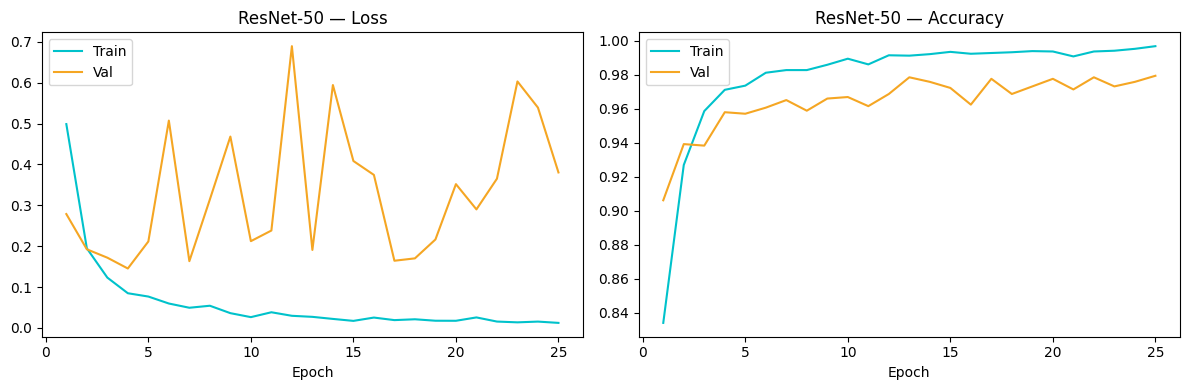

In [11]:
plot_learning_curves(train_losses, val_losses, train_accs, val_accs,
                      model_name="ResNet-50",
                      save_path='/content/drive/MyDrive/brain-tumour-mri-classification/results/figures/resnet50_learning_curves.png')


Results for: ResNet-50
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.90      0.91      0.91       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600

ROC-AUC (OvR): 0.9855


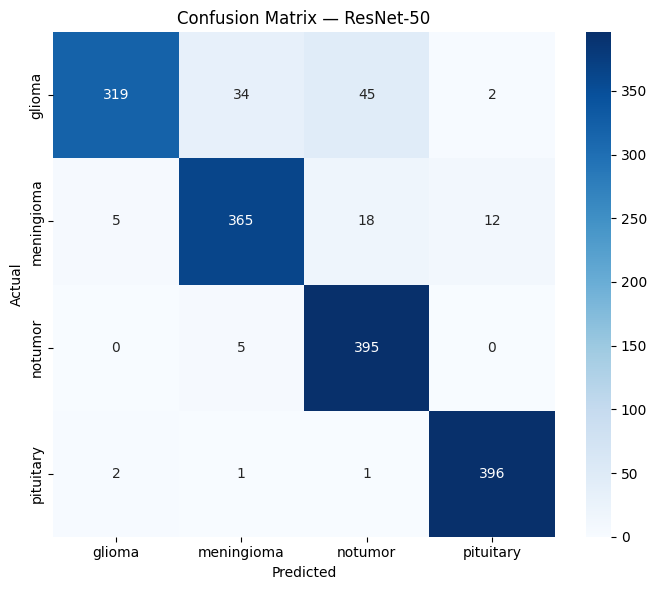

In [12]:
!mkdir -p "/content/drive/MyDrive/brain-tumour-mri-classification/results/metrics"

# Load the epoch 4 checkpoint weights (overwrites the epoch 25 weights currently in memory)
resnet.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
resnet.eval()

y_true, y_pred, y_probs = evaluate_model(resnet, test_loader, device, model_name="ResNet-50")
print_metrics(y_true, y_pred, y_probs, model_name="ResNet-50")
plot_confusion_matrix(y_true, y_pred, model_name="ResNet-50",
                       save_path='/content/drive/MyDrive/brain-tumour-mri-classification/results/figures/resnet50_confusion_matrix.png')

In [2]:
from google.colab import drive, userdata
drive.mount('/content/drive')

token = userdata.get('GITHUB_TOKEN')
!git clone -b feature/resnet50 https://{token}@github.com/Dini-s/brain-tumour-mri-classification.git

import sys
sys.path.append('/content/brain-tumour-mri-classification')

import torch
import torch.nn as nn
import torchvision.models as models
from src.dataset import get_dataloaders
from src.utils import evaluate_model, plot_confusion_matrix, plot_learning_curves, print_metrics

!mkdir -p /content/data
!cp -r "/content/drive/MyDrive/brain-tumour-mri-classification/data/Training" /content/data/
!cp -r "/content/drive/MyDrive/brain-tumour-mri-classification/data/Testing" /content/data/

DATA_ROOT = '/content/data'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, val_loader, test_loader = get_dataloaders(DATA_ROOT, batch_size=32)

# Rebuild the architecture (no need to re-download ImageNet weights, we're loading our own)
resnet = models.resnet50(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)

CHECKPOINT_PATH = '/content/drive/MyDrive/brain-tumour-mri-classification/results/checkpoints/resnet50_best.pth'
resnet.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
resnet = resnet.to(device)
resnet.eval()
print("Checkpoint loaded — ready")

Mounted at /content/drive
Cloning into 'brain-tumour-mri-classification'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 28 (delta 5), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 8.85 KiB | 8.85 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']
Checkpoint loaded — ready


In [3]:
import time
start = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _ = resnet(images)
inference_time = time.time() - start
print(f"Total inference time on test set: {inference_time:.2f}s ({inference_time/len(test_loader.dataset)*1000:.2f} ms/image)")

Total inference time on test set: 7.33s (4.58 ms/image)


In [4]:
# Regenerate predictions (fast, same model already loaded)
y_true, y_pred, y_probs = evaluate_model(resnet, test_loader, device, model_name="ResNet-50")

from sklearn.metrics import classification_report, roc_auc_score

report_text = classification_report(y_true, y_pred,
                                     target_names=['glioma', 'meningioma', 'notumor', 'pituitary'])
auc = roc_auc_score(y_true, y_probs, multi_class='ovr')

metrics_text = f"""ResNet-50 Test Set Results
{'='*50}
{report_text}
ROC-AUC (OvR): {auc:.4f}
Inference time: 7.33s total ({7.33/1600*1000:.2f} ms/image)
"""

print(metrics_text)

import os
os.makedirs('/content/drive/MyDrive/brain-tumour-mri-classification/results/metrics', exist_ok=True)
with open('/content/drive/MyDrive/brain-tumour-mri-classification/results/metrics/resnet50_metrics.txt', 'w') as f:
    f.write(metrics_text)

print("Saved to Drive")

ResNet-50 Test Set Results
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.90      0.91      0.91       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600

ROC-AUC (OvR): 0.9855
Inference time: 7.33s total (4.58 ms/image)

Saved to Drive
